# XOR Test
Train a network with 1 hidden layer of 2 nodes to solve XOR, once with sigmoid and once with tanh activations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nnlib import LinearLayer, SigmoidFunction, Tanh, Sequential, BinaryCrossEntropyLoss

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).astype(float)
y = np.array([[0], [1], [1], [0]]).astype(float)

In [2]:
def train_xor(activation, lr, epochs, seed=None):
    """
    Build and train a network with 1 hidden layer of 2 nodes on the XOR problem.

    Architecture:
        LinearLayer(2, 2) -> activation() -> LinearLayer(2, 1) -> SigmoidFunction()
    The network is trained with binary cross-entropy loss and plain gradient descent,
    using the global X and y defined above.

    Each epoch runs: forward pass -> loss -> loss backward -> network backward -> weight update.

    Parameters:
        activation (class): Activation class for the hidden layer, e.g. SigmoidFunction or Tanh.
                            Pass the class itself, not an instance (no parentheses).
        lr (float): Learning rate used by model.step().
        epochs (int): Number of training iterations over the full XOR dataset.
        seed (int, optional): Random seed for the weight initialization, so a run can be
                              reproduced exactly. If None, the weights are random each time.

    Returns:
        tuple:
            model (Sequential): The trained network.
            losses (list[float]): The loss value recorded at every epoch, for plotting.
    """
    if seed is not None:
        np.random.seed(seed)

    model = Sequential([
        LinearLayer(2,2),
        activation(),
        LinearLayer(2,1),
        SigmoidFunction()
    ]) 

    loss_fn = BinaryCrossEntropyLoss()
    losses = []

    for epoch in range(epochs):
        # Forward pass
        y_pred = model.forward(X)

        # Compute loss
        loss = loss_fn.forward(y_pred, y)
        losses.append(loss)

        # Backward pass
        loss_grad = loss_fn.backward()
        model.backward(loss_grad)

        # Update weights
        model.step(lr)

    return model, losses


In [3]:
def is_solved(model):
    """
    Check whether a trained model classifies all four XOR inputs correctly.

    Parameters:
        model (Sequential): The trained network.

    Returns:
        bool: True if every prediction, rounded to 0 or 1, matches its label in y.
    """
    return bool(np.all(np.round(model.forward(X)) == y))


def show_results(model, losses, title):
    """
    Plot the training loss curve and print the model's predictions next to the targets.

    Parameters:
        model (Sequential): The trained network.
        losses (list[float]): Loss value recorded at every epoch.
        title (str): Title for the plot.
    """
    plt.figure(figsize=(6, 3.5))
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Binary cross-entropy loss")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

    pred = model.forward(X)
    print("input   target   prediction   rounded")
    for xi, yi, pi in zip(X, y, pred):
        print(f"{xi.astype(int)}    {int(yi[0])}       {pi[0]:.4f}        {int(round(pi[0]))}")
    print("Solved:", is_solved(model))

## 1. Sigmoid hidden activation

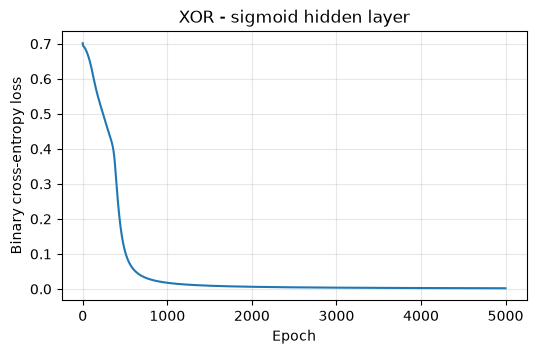

input   target   prediction   rounded
[0 0]    0       0.0018        0
[0 1]    1       0.9981        1
[1 0]    1       0.9981        1
[1 1]    0       0.0028        0
Solved: True


In [4]:
model_sigmoid, losses_sigmoid = train_xor(SigmoidFunction, lr=1.0, epochs=5000, seed=1)
show_results(model_sigmoid, losses_sigmoid, "XOR - sigmoid hidden layer")

## 2. Tanh hidden activation

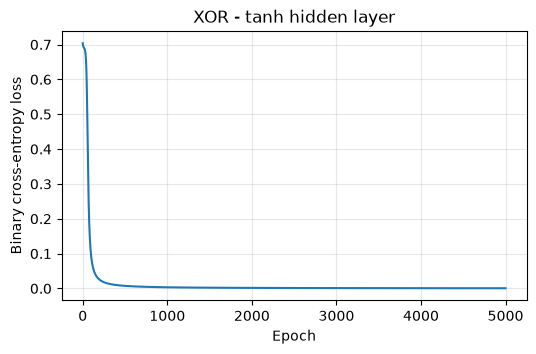

input   target   prediction   rounded
[0 0]    0       0.0005        0
[0 1]    1       0.9992        1
[1 0]    1       0.9992        1
[1 1]    0       0.0004        0
Solved: True


In [5]:
model_tanh, losses_tanh = train_xor(Tanh, lr=1.0, epochs=5000, seed=3)
show_results(model_tanh, losses_tanh, "XOR - tanh hidden layer")

## 3. Comparing sigmoid and tanh over many attempts

A single run depends on the random starting weights, so each activation is trained from 50 different seeds.
For each one we record:
- how many runs solved XOR
- for the runs that solved it, how many epochs it took for the loss to drop below 0.1

Sigmoid  solved 39/50 runs | median epochs to loss < 0.1: 529


Tanh     solved 25/50 runs | median epochs to loss < 0.1: 102


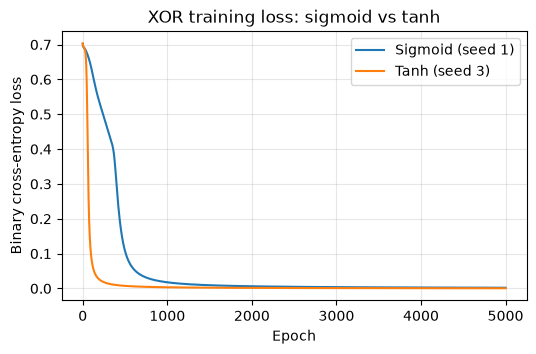

In [6]:
def epochs_to_threshold(losses, threshold=0.1):
    """
    Return the first epoch at which the loss fell below the threshold, or None if it never did.

    Parameters:
        losses (list[float]): Loss value recorded at every epoch.
        threshold (float): Loss value that counts as converged.

    Returns:
        int or None: The first epoch below the threshold, or None.
    """
    for epoch, loss in enumerate(losses):
        if loss < threshold:
            return epoch
    return None


n_seeds = 50
for name, activation in [("Sigmoid", SigmoidFunction), ("Tanh", Tanh)]:
    solved_epochs = []
    for seed in range(n_seeds):
        model, losses = train_xor(activation, lr=1.0, epochs=5000, seed=seed)
        if is_solved(model):
            solved_epochs.append(epochs_to_threshold(losses))
    reached = [e for e in solved_epochs if e is not None]
    print(f"{name:8s} solved {len(solved_epochs):2d}/{n_seeds} runs | "
          f"median epochs to loss < 0.1: {np.median(reached):.0f}")

plt.figure(figsize=(6, 3.5))
plt.plot(losses_sigmoid, label="Sigmoid (seed 1)")
plt.plot(losses_tanh, label="Tanh (seed 3)")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("XOR training loss: sigmoid vs tanh")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. Saving and loading the solved model

The sigmoid model above solved XOR, so its weights are saved to `models/XOR_solved.w`.
A brand new network with the same architecture is then built, the weights are loaded into it,
and its predictions are compared with the original model to confirm saving and loading work.

In [7]:
assert is_solved(model_sigmoid), "Pick a seed that solves XOR before saving."
model_sigmoid.save("models/XOR_solved.w")

loaded_model = Sequential([
    LinearLayer(2, 2),
    SigmoidFunction(),
    LinearLayer(2, 1),
    SigmoidFunction()
])
loaded_model.load("models/XOR_solved.w")

print("Original predictions:", model_sigmoid.forward(X).ravel().round(4))
print("Loaded predictions:  ", loaded_model.forward(X).ravel().round(4))
print("Identical:", np.allclose(model_sigmoid.forward(X), loaded_model.forward(X)))
print("Loaded model solves XOR:", is_solved(loaded_model))

Original predictions: [0.0018 0.9981 0.9981 0.0028]
Loaded predictions:   [0.0018 0.9981 0.9981 0.0028]
Identical: True
Loaded model solves XOR: True


## 5. Which activation was easier to train?

With the architecture from the assignment (2 inputs, 1 hidden layer of 2 nodes, 1 sigmoid output),
learning rate 1.0 and 5000 epochs, over 50 random seeds:

| Hidden activation | Runs that solved XOR | Median epochs to reach loss < 0.1 |
|---|---|---|
| Sigmoid | 39 / 50 | about 530 |
| Tanh | 25 / 50 | about 100 |

**Sigmoid was easier to train for this problem**, in the sense that it solved XOR far more reliably:
about 4 out of 5 attempts succeeded, against only half for tanh. The failed runs get stuck in a
local minimum where two of the four inputs are predicted as 0.5. With only 2 hidden nodes there is
no spare capacity, so a bad starting point is hard to escape, and tanh hit those dead ends more often.

**Tanh was faster when it did work**, reaching a low loss about 5 times sooner. Tanh outputs are
centered at 0 and its derivative is up to 1.0 (sigmoid's is at most 0.25), so gradients are larger
and each step moves the weights further.

In short: tanh learns faster, but sigmoid is more reliable here, so with this small network sigmoid
needed fewer attempts to get a working solution.